In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv(r"C:\Users\User\Downloads/Automobile_data.csv")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset info:")
df.info()

Dataset shape: (205, 26)

First 5 rows:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size

In [6]:
df.replace(['?','NA',''], np.nan, inplace=True)
df.isnull().sum()   # which columns have missing values

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [7]:
#Convert columns to numeric
#Plain: numeric columns may be strings — convert them so you can compute.
num_cols = ['price','horsepower','engine-size','city-mpg','highway-mpg',
            'curb-weight','length','width']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')   # invalid -> NaN

In [8]:
#Handle missing values simply
#Plain: numeric → median; categorical → mode (most common).

for c in num_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

# categorical impute
cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

In [9]:
#Basic feature engineering
#Plain: create features that help explain price/performance.
# area from width & length (if present)
if 'width' in df.columns and 'length' in df.columns:
    df['area'] = df['width'] * df['length']

# power-to-weight
if {'horsepower','curb-weight'}.issubset(df.columns):
    df['power_to_weight'] = df['horsepower'] / df['curb-weight']

In [10]:
#Answering the Key Questions
#If price is object type (string), convert to numeric
#Sometimes price column is stored as text.
#Q.1 What are the major factors influencing vehicle price?

# convert price to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# select only numeric columns
num_df = df.select_dtypes(include=['int64','float64'])

# correlation with price
corr = num_df.corr()['price'].sort_values(ascending=False)
corr

price                1.000000
engine-size          0.860343
curb-weight          0.819817
horsepower           0.749919
area                 0.729786
width                0.724558
length               0.686567
wheel-base           0.584847
power_to_weight      0.471574
height               0.140439
compression-ratio    0.072890
symboling           -0.080149
city-mpg            -0.668822
highway-mpg         -0.693037
Name: price, dtype: float64

In [11]:
#Q.2 How does brand reputation (e.g., BMW vs. Toyota) correlate with pricing?
#Brand reputation vs price (BMW vs Toyota)
avg_price_by_make = df.groupby('make')['price'].mean().sort_values(ascending=False)
print(avg_price_by_make.head(10))   # luxury brands will appear near top

make
jaguar           34600.000000
mercedes-benz    33647.000000
porsche          27179.400000
bmw              26118.750000
volvo            18063.181818
audi             16778.571429
mercury          16503.000000
alfa-romero      15498.333333
peugot           15489.090909
saab             15223.333333
Name: price, dtype: float64


In [12]:
#Engine & Performance Insights
#Q.1 Do larger engines and higher horsepower lead to higher prices?
df[['engine-size','horsepower','price']].corr()
# or visualize with scatter (below)

,engine-size,horsepower,price
engine-size,1.000000,0.810216,0.860343
horsepower,0.810216,1.000000,0.749919
price,0.860343,0.749919,1.000000


In [13]:
#Q.2 How do different fuel types affect performance and cost?
df.groupby('fuel-type')[['price','city-mpg','highway-mpg']].mean()

,price,city-mpg,highway-mpg
fuel-type,,,
diesel,15838.15000,30.30000,34.750000
gas,12859.72973,24.67027,30.318919


In [14]:
#Design & Drive Style Analysis
#Q1. Are certain body styles or drive types more expensive?
df.groupby('body-style')['price'].median().sort_values()
df.groupby('drive-wheels')['price'].median().sort_values()

drive-wheels
fwd     8222.0
4wd     9233.0
rwd    16872.5
Name: price, dtype: float64

           width    height      area     price
width   1.000000  0.279210  0.720401  0.724558
height  0.279210  1.000000  0.866721  0.140439
area    0.720401  0.866721  1.000000  0.477898
price   0.724558  0.140439  0.477898  1.000000


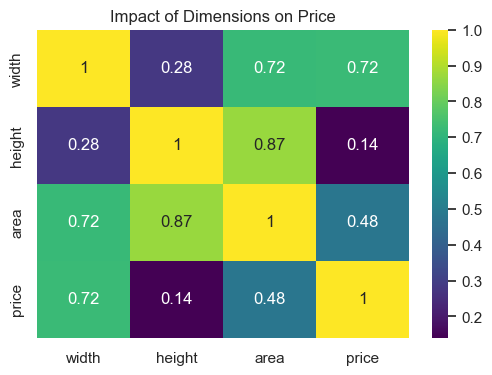

In [15]:
#Q.2 What impact do dimensions (length, width, weight) have on pricing?
# Ensure numeric
df['width'] = pd.to_numeric(df['width'], errors='coerce')
df['height'] = pd.to_numeric(df['height'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Fill missing values
df['width'] = df['width'].fillna(df['width'].median())
df['height'] = df['height'].fillna(df['height'].median())
df['price'] = df['price'].fillna(df['price'].median())

# Create area feature
df['area'] = df['width'] * df['height']

# Correlation of dimensions with price
corr = df[['width','height','area','price']].corr()
print(corr)

# Optional: Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title("Impact of Dimensions on Price")
plt.show()

In [17]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# List of numeric columns in your dataset
numeric_cols = ['symboling', 'normalized-losses', 'width', 'height',
                'engine-size', 'horsepower', 'city-mpg', 'highway-mpg', 'price']

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert invalid entries to NaN

# Fill missing numeric values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

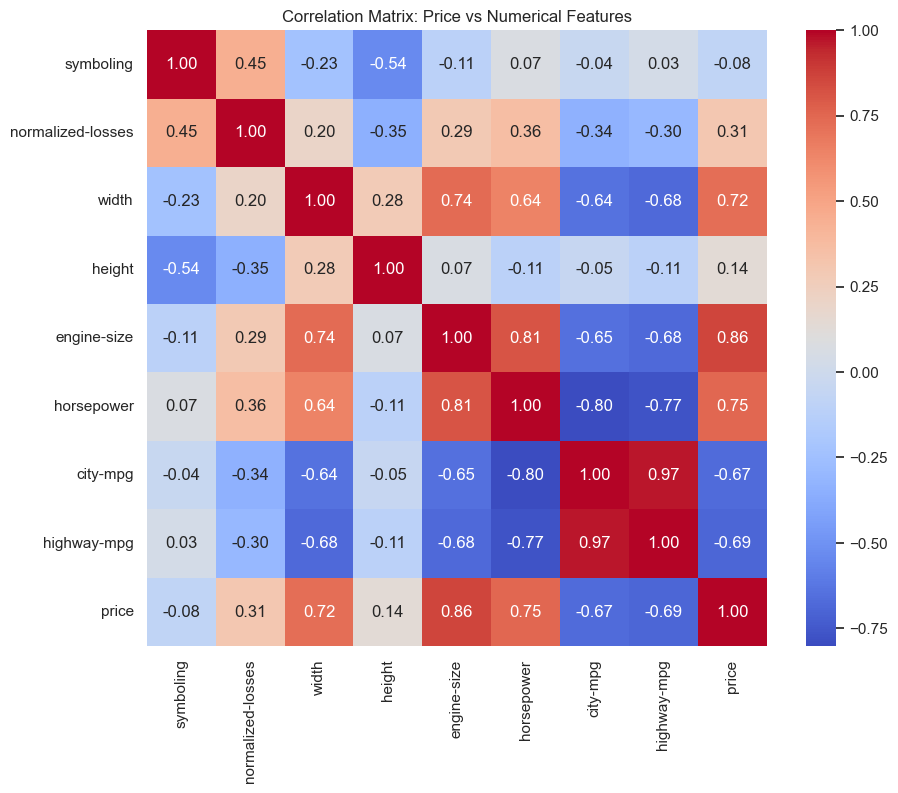

In [18]:

# 1. Correlation Heatmap – Price vs. Numerical Features
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix: Price vs Numerical Features')
plt.show()


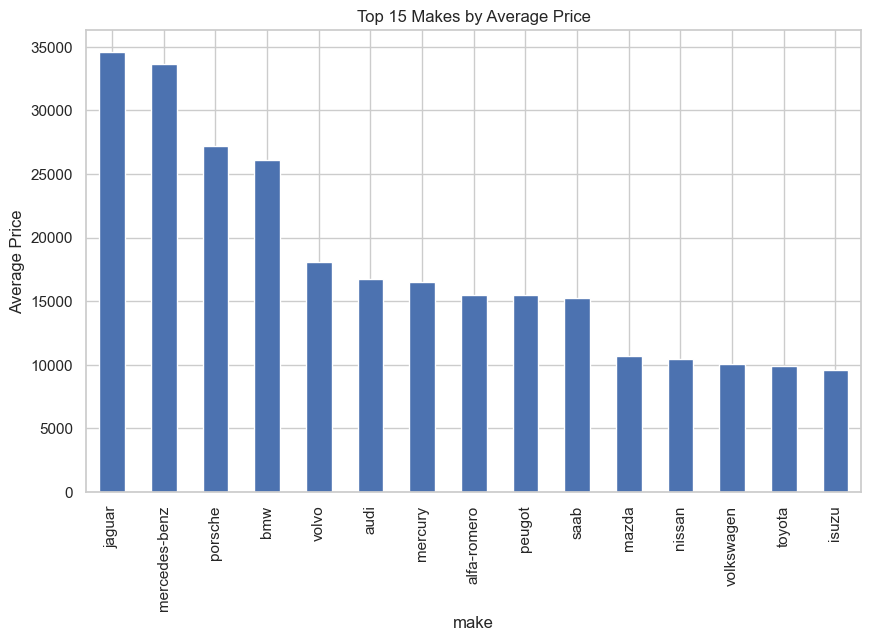

In [19]:
# 2. Bar Charts – Average Price by Brand or Fuel Type
top_makes = df.groupby('make')['price'].mean().sort_values(ascending=False).head(15)
top_makes.plot(kind='bar')
plt.ylabel('Average Price')
plt.title('Top 15 Makes by Average Price')
plt.show()

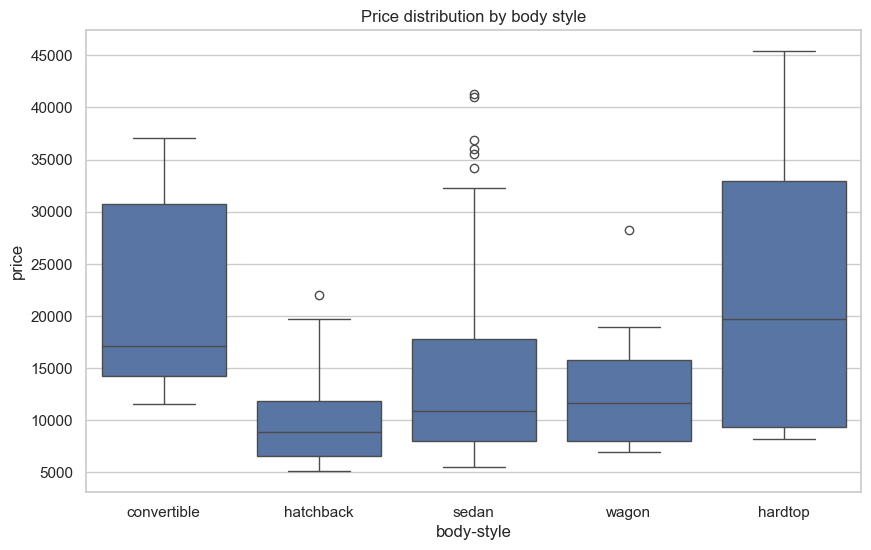

In [20]:
# 3. Boxplots – Price Distribution Across Body Styles
sns.boxplot(x='body-style', y='price', data=df)
plt.title('Price distribution by body style')
plt.show()

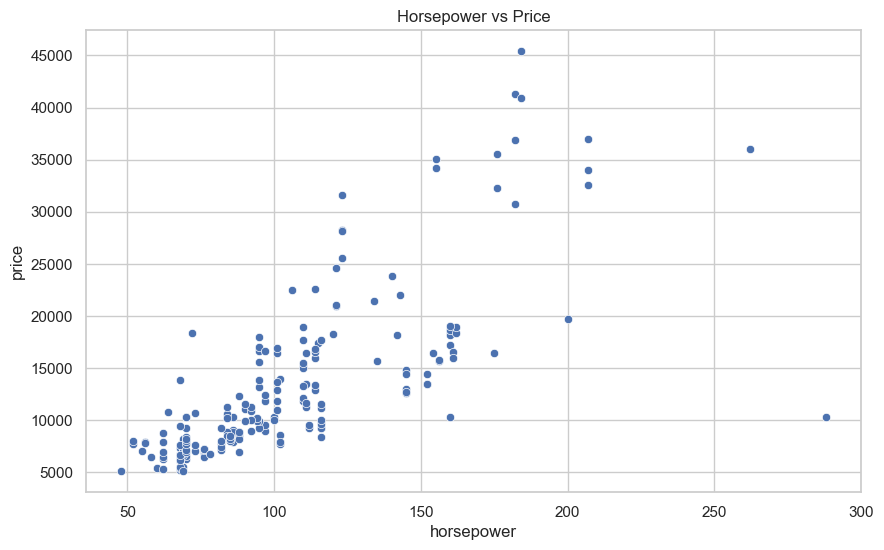

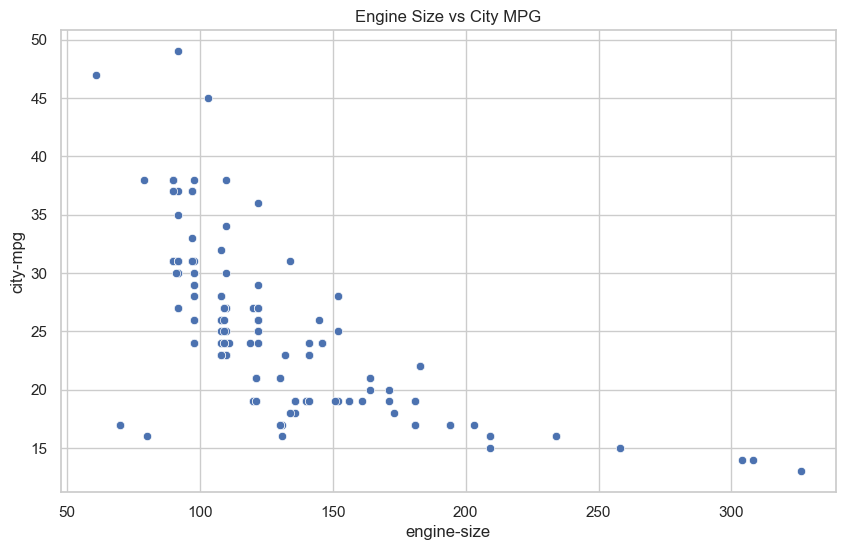

In [21]:
# 4. Scatter Plots – Horsepower vs. Price, Engine Size vs. MPG
sns.scatterplot(x='horsepower', y='price', data=df)
plt.title('Horsepower vs Price')
plt.show()

sns.scatterplot(x='engine-size', y='city-mpg', data=df)
plt.title('Engine Size vs City MPG')
plt.show()

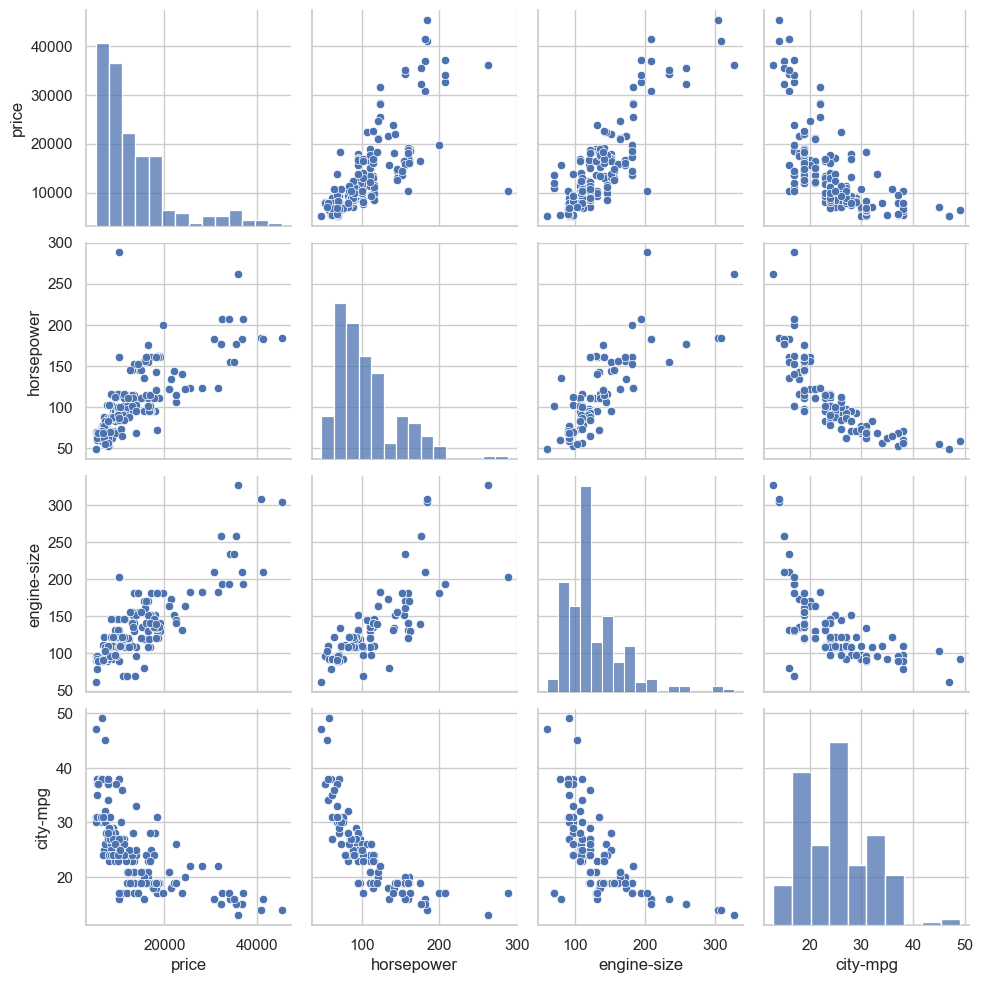

In [22]:
# 5. Pairplot – Multivariate Pattern Exploration
sns.pairplot(df[['price','horsepower','engine-size','city-mpg']].sample(200))
plt.show()